# 0. 환경설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import seaborn as sns
from scipy import stats
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Windows)
plt.rcParams['axes.unicode_minus'] = False

# 1. 개요 — 04번 8장 질문 6개 검증

04_StuXAss.ipynb의 8장(`다른 CSV 파일과 더 연관지어야 확인할 수 있는 것들`)에서 정리한 6개 질문을 실제로 조인해서 확인한다.

1. **courses.csv**: `module_presentation_length`, 개강 시즌(B/J)을 통제하면 Q5(과목별 이탈률 차이)가 과목 자체 문제인지 학기 구조 문제인지 분리되는가? `code_presentation`(학기)별 이탈률 차이는?
2. **studentRegistration.csv의 `date_unregistration`**: 마지막 제출일과 실제 등록취소일 사이의 간격은?
3. **studentVle.csv**: 이탈 그룹은 마지막 제출 전후로 온라인 활동이 줄었는가? 제출 이력이 없는 고위험군도 VLE 기록은 남겼는가?
4. **studentInfo.csv 전체(32,593건) 기준 이탈률**: 제출 이력 기준 이탈률과 항상 병기했을 때 차이는 얼마나 나는가?
5. **is_banked 해석**: `date_registration`(등록 시점)과 비교했을 때 is_banked=1 학생은 실제로 등록이 늦었는가?
6. **미제출 평가(결석) 식별**: assessments.csv의 전체 평가 로스터와 실제 제출 목록을 비교해 학생별 미제출 평가(및 그 weight)를 파생시키고, 04번 7장 Q6에서 확인하지 못했던 "비중이 큰 평가를 놓친 학생일수록 이탈 확률이 높은가"를 직접 검증한다.

# 2. 데이터 로드 및 조인 준비

In [3]:
info = pd.read_csv('../../CSV_files/studentInfo.csv')
info['label_churn'] = (info['final_result'] == 'Withdrawn').astype(int)

sa = pd.read_csv('../../CSV_files/studentAssessment.csv')
asm = pd.read_csv('../../CSV_files/assessments.csv')
courses = pd.read_csv('../../CSV_files/courses.csv')
reg = pd.read_csv('../../CSV_files/studentRegistration.csv')

# 04번과 동일한 기준 조인 테이블
df = sa.merge(asm, on='id_assessment', how='left')
df = df.merge(info[['code_module', 'code_presentation', 'id_student', 'final_result', 'label_churn']],
              on=['code_module', 'code_presentation', 'id_student'], how='left')
df['delay'] = df['date_submitted'] - df['date']

# 학생-과목 단위 roster (studentInfo 전체 기준, 제출 이력 유무와 무관)
roster = info[['code_module', 'code_presentation', 'id_student', 'label_churn', 'final_result']].drop_duplicates()

# 제출 이력이 있는 학생-과목 조합
submitted_keys = sa.merge(asm[['id_assessment', 'code_module', 'code_presentation']], on='id_assessment', how='left')\
    [['code_module', 'code_presentation', 'id_student']].drop_duplicates()

print(f'info: {len(info):,}건 / df(제출 기록): {len(df):,}건 / roster(학생-과목): {len(roster):,}건')

info: 32,593건 / df(제출 기록): 173,912건 / roster(학생-과목): 32,593건


## Q1. courses.csv 조인 — 과목 길이·개강 시즌 통제

#### 배경

04번 7장 Q5에서 `code_module`별 이탈률 차이(CCC 최고, GGG 최저)를 확인했지만, 이것이 과목 설계 자체의 문제인지 학기 구조(길이·시즌)의 문제인지는 구분하지 못했다. `code_presentation`(학기)별 차이도 아직 따로 보지 않았다.

In [4]:
# 근거 : code_presentation(학기)별 이탈률 — studentInfo 전체 기준
churn_by_pres = info.groupby('code_presentation')['label_churn'].mean().round(4)
print('code_presentation별 이탈률:')
print(churn_by_pres)
print()

# 근거 : module_presentation_length·개강 시즌과 이탈률의 관계
mp_churn = info.groupby(['code_module', 'code_presentation'])['label_churn'].mean().reset_index()
mp_churn = mp_churn.merge(courses, on=['code_module', 'code_presentation'], how='left')
mp_churn['season'] = mp_churn['code_presentation'].str[-1]  # B=2월, J=10월 개강

corr = mp_churn['module_presentation_length'].corr(mp_churn['label_churn'])
print('module_presentation_length vs 이탈률 상관계수:', round(corr, 4))
print()
print('개강 시즌(season)별 평균 이탈률:')
print(mp_churn.groupby('season')['label_churn'].mean().round(4))
print()
print('과목×학기 조합별 이탈률 (내림차순):')
print(mp_churn.sort_values('label_churn', ascending=False).to_string(index=False))

code_presentation별 이탈률:
code_presentation
2013B    0.2878
2013J    0.2678
2014B    0.3348
2014J    0.3398
Name: label_churn, dtype: float64

module_presentation_length vs 이탈률 상관계수: -0.1706

개강 시즌(season)별 평균 이탈률:
season
B    0.3018
J    0.2674
Name: label_churn, dtype: float64

과목×학기 조합별 이탈률 (내림차순):
code_module code_presentation  label_churn  module_presentation_length season
        CCC             2014B     0.463843                         241      B
        CCC             2014J     0.431145                         269      J
        DDD             2014B     0.399023                         241      B
        FFF             2014J     0.361522                         269      J
        DDD             2014J     0.358846                         262      J
        DDD             2013J     0.351393                         261      J
        DDD             2013B     0.331543                         240      B
        BBB             2014J     0.326789                         262     

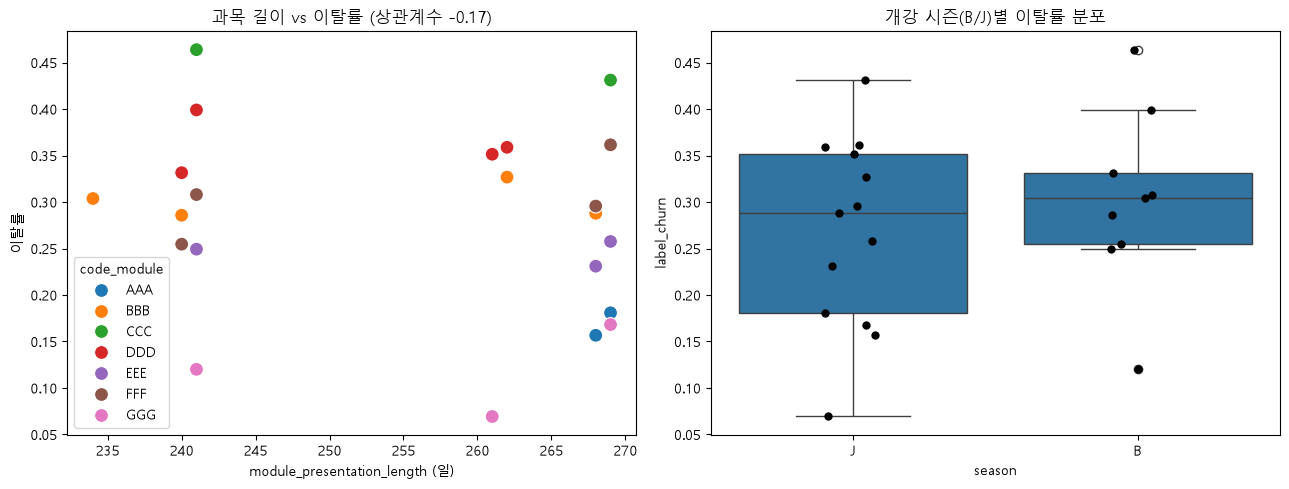

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=mp_churn, x='module_presentation_length', y='label_churn', hue='code_module', s=100, ax=axes[0])
axes[0].set_title(f'과목 길이 vs 이탈률 (상관계수 {corr:.2f})')
axes[0].set_xlabel('module_presentation_length (일)')
axes[0].set_ylabel('이탈률')

sns.boxplot(data=mp_churn, x='season', y='label_churn', ax=axes[1])
sns.stripplot(data=mp_churn, x='season', y='label_churn', color='black', size=6, ax=axes[1])
axes[1].set_title('개강 시즌(B/J)별 이탈률 분포')

plt.tight_layout()
plt.show()

#### 설명

학기 길이(`module_presentation_length`)와 이탈률의 상관계수는 **-0.17**로 뚜렷한 선형 관계라 보기 어렵다. 개강 시즌별로는 B(2월 개강) 이탈률 30.2%, J(10월 개강) 이탈률 26.7%로 B 시즌이 다소 높지만 차이가 크지 않다.

반면 과목×학기 조합별 표를 보면 CCC 2014B(46.4%), CCC 2014J(43.1%), DDD 2014B(39.9%) 등 상위권이 모두 CCC·DDD 두 과목에 몰려 있고, GGG 2013J(6.9%)·AAA 2013J(15.7%) 등 하위권도 특정 과목에 몰려 있다. 즉 이탈률 차이는 학기 길이나 시즌 같은 구조적 요인보다 **과목(code_module) 자체의 효과**로 설명하는 편이 더 타당해 보인다. 04번 Q5의 결론(과목별 이탈률 차이)은 이 조인으로도 유지된다.

다만 code_presentation 자체의 효과(B/J)는 크지 않아, 04번에서 다루지 않았던 이 축은 새로운 정보를 크게 더하지 않는다는 것도 확인된 셈이다.

## Q2. studentRegistration.csv 조인 — 마지막 제출일과 실제 이탈(등록취소)일 간격

#### 배경

이 3단계 조인 계획을 시작한 핵심 목적이기도 하다. `date_unregistration`을 조인하면 학생이 언제 공식적으로 이탈했는지 알 수 있고, 이를 마지막 제출일(`date_submitted`의 최댓값)과 비교하면 "제출을 멈춘 시점"과 "공식적으로 이탈한 시점" 사이의 간격을 확인할 수 있다.

In [6]:
# 근거 : 학생별 마지막 제출일
last_sub = df.groupby(['code_module', 'code_presentation', 'id_student'])['date_submitted'].max().reset_index()
last_sub.columns = ['code_module', 'code_presentation', 'id_student', 'last_submit_date']

# 근거 : Withdrawn 학생만 대상으로 등록취소일자·마지막 제출일 조인
wd = roster[roster['final_result'] == 'Withdrawn'].merge(
    reg, on=['code_module', 'code_presentation', 'id_student'], how='left')
wd = wd.merge(last_sub, on=['code_module', 'code_presentation', 'id_student'], how='left')

print('Withdrawn 학생 수:', len(wd))
print('date_unregistration 결측(취소일 기록 없음):', wd['date_unregistration'].isna().sum())
print('last_submit_date 결측(제출 이력 자체 없음):', wd['last_submit_date'].isna().sum())
print()

# 근거 : 둘 다 존재하는 경우의 간격(gap = 취소일 - 마지막 제출일)
both = wd.dropna(subset=['date_unregistration', 'last_submit_date']).copy()
both['gap'] = both['date_unregistration'] - both['last_submit_date']
print(f'취소일·마지막 제출일 둘 다 있는 Withdrawn: {len(both):,}건')
print(both['gap'].describe().round(2))
print('gap<0(취소가 마지막 제출보다 먼저) 비율:', round((both['gap'] < 0).mean(), 3))
print('|gap|<=7일 비율:', round((both['gap'].abs() <= 7).mean(), 3))
print()

# 근거 : 제출 이력 자체가 없는 Withdrawn의 취소 시점
no_sub = wd[wd['last_submit_date'].isna()]
print(f'제출 이력 없는 Withdrawn: {len(no_sub):,}건, date_unregistration describe:')
print(no_sub['date_unregistration'].describe().round(2))

Withdrawn 학생 수: 10156
date_unregistration 결측(취소일 기록 없음): 93
last_submit_date 결측(제출 이력 자체 없음): 5463

취소일·마지막 제출일 둘 다 있는 Withdrawn: 4,671건
count    4671.00
mean       39.38
std        55.39
min      -490.00
25%        15.00
50%        34.00
75%        59.00
max       324.00
Name: gap, dtype: float64
gap<0(취소가 마지막 제출보다 먼저) 비율: 0.088
|gap|<=7일 비율: 0.102

제출 이력 없는 Withdrawn: 5,463건, date_unregistration describe:
count    5392.00
mean       -3.62
std        55.40
min      -365.00
25%       -23.00
50%         0.00
75%        12.00
max       240.00
Name: date_unregistration, dtype: float64


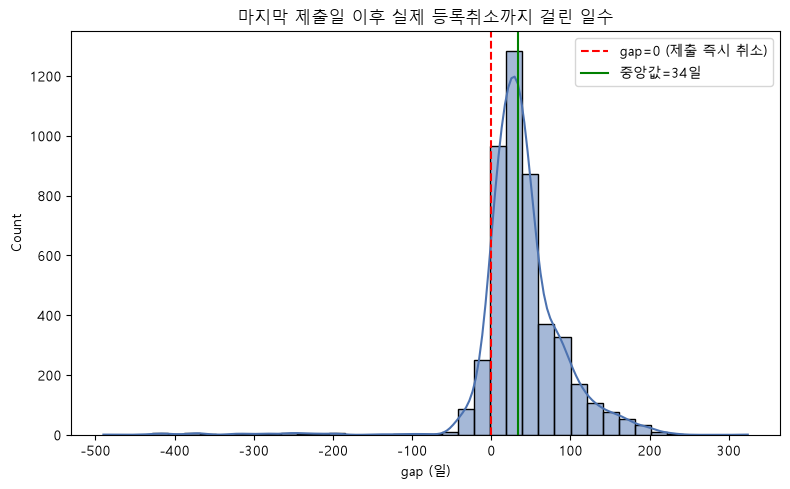

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(both['gap'], bins=40, kde=True, color='#4C72B0')
ax.axvline(0, color='red', linestyle='--', label='gap=0 (제출 즉시 취소)')
ax.axvline(both['gap'].median(), color='green', linestyle='-', label=f"중앙값={both['gap'].median():.0f}일")
ax.set_title('마지막 제출일 이후 실제 등록취소까지 걸린 일수')
ax.set_xlabel('gap (일)')
ax.legend()
plt.tight_layout()
plt.show()

#### 설명

Withdrawn 10,156명 중 취소일·마지막 제출일이 둘 다 있는 4,671명(46.0%)만 보면, 제출을 멈춘 뒤 평균 **39.4일(중앙값 34일)** 뒤에 공식적으로 등록이 취소된다. 즉 대부분의 학생은 마지막 제출 후에도 한 달 이상 '재적' 상태로 남아 있다가 취소 처리된다 — 제출 중단과 공식 이탈 사이에 상당한 시차가 있다는 뜻이다. gap이 음수(취소가 제출보다 먼저 기록됨)인 경우는 8.8%뿐이라 대부분 제출 중단 → 취소 순서가 맞다.

반면 제출 이력 자체가 없는 5,392명(전체 Withdrawn의 53.1%)은 애초에 '마지막 제출일'이라는 기준점이 없으므로 이 gap을 계산할 수 없다. 이들의 등록취소일 자체는 중앙값 0일(개강 시점 부근)로, 대부분 학기 시작 직후 혹은 시작 전에 이탈한 것으로 보인다. 04번 Q1에서 확인한 '제출 이력 없는 고위험군'이 바로 이 조기 이탈 그룹과 겹친다는 것을 뒷받침한다.

## Q3. studentVle.csv 조인 — 온라인 학습활동과 이탈

#### 배경

이탈 그룹의 온라인 학습활동(클릭 수)이 실제로 줄었는지, 그리고 04번 Q1에서 확인한 '제출 이력 자체가 없는' 고위험군도 로그인/클릭 기록은 남겼는지(완전히 발길을 끊은 건 아닌지) 확인한다.

studentVle.csv는 10,655,280행(약 433MB)으로 행 단위로 다루기엔 크기 때문에, 학생-과목 단위로 총 클릭 수·활동 일수를 먼저 집계한다.

In [8]:
# 근거 : studentVle.csv를 학생-과목 단위로 집계 (총 클릭 수, 활동 일수, 마지막 접속일)
vle = pd.read_csv('../../CSV_files/studentVle.csv')
vle_agg = vle.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    total_click=('sum_click', 'sum'),
    active_days=('date', 'nunique'),
    last_active_date=('date', 'max')
).reset_index()
print(f'studentVle.csv: {len(vle):,}행 -> 학생-과목 집계: {len(vle_agg):,}건')

studentVle.csv: 10,655,280행 -> 학생-과목 집계: 29,228건


In [20]:
# 근거 : label_churn별 VLE 기록 유무·활동량
r = roster.merge(vle_agg, on=['code_module', 'code_presentation', 'id_student'], how='left')
r['has_vle'] = r['total_click'].notna()

print('VLE 기록이 있는 학생 비율(전체):', round(r['has_vle'].mean(), 4))
print('label_churn별 VLE 기록 있음 비율:')
print(r.groupby('label_churn')['has_vle'].mean().round(4))
print()
print('label_churn별 total_click / active_days (VLE 기록이 있는 학생만):')
print(r[r['has_vle']].groupby('label_churn')[['total_click', 'active_days', 'last_active_date']].agg(['mean', 'median']).round(1))
print()

# 근거 : 제출 이력이 없는 고위험군 중 VLE 기록 유무
r2 = roster.merge(submitted_keys.assign(has_submission=True),
                   on=['code_module', 'code_presentation', 'id_student'], how='left')
r2['has_submission'] = r2['has_submission'].notna()  # True/NaN -> bool (fillna 다운캐스팅 이슈 회피)
r2 = r2.merge(vle_agg, on=['code_module', 'code_presentation', 'id_student'], how='left')
r2['has_vle'] = r2['total_click'].notna()

print('제출 이력 없는 그룹 중 VLE 기록 있는 비율:', round(r2[~r2['has_submission']]['has_vle'].mean(), 4))
print('제출 이력 있는 그룹 중 VLE 기록 있는 비율:', round(r2[r2['has_submission']]['has_vle'].mean(), 4))
print()
print('제출 이력 없는 그룹 내에서 label_churn별 VLE 기록 있는 비율:')
print(r2[~r2['has_submission']].groupby('label_churn')['has_vle'].mean().round(4))

VLE 기록이 있는 학생 비율(전체): 0.8968
label_churn별 VLE 기록 있음 비율:
label_churn
0    0.9832
1    0.7058
Name: has_vle, dtype: float64

label_churn별 total_click / active_days (VLE 기록이 있는 학생만):
            total_click         active_days        last_active_date       
                   mean  median        mean median             mean median
label_churn                                                               
0                1650.8  1030.0        74.5   63.0            212.2  236.0
1                 444.8   221.5        23.1   15.0             69.7   51.0

제출 이력 없는 그룹 중 VLE 기록 있는 비율: 0.5089
제출 이력 있는 그룹 중 VLE 기록 있는 비율: 0.9981

제출 이력 없는 그룹 내에서 label_churn별 VLE 기록 있는 비율:
label_churn
0    0.7304
1    0.4567
Name: has_vle, dtype: float64


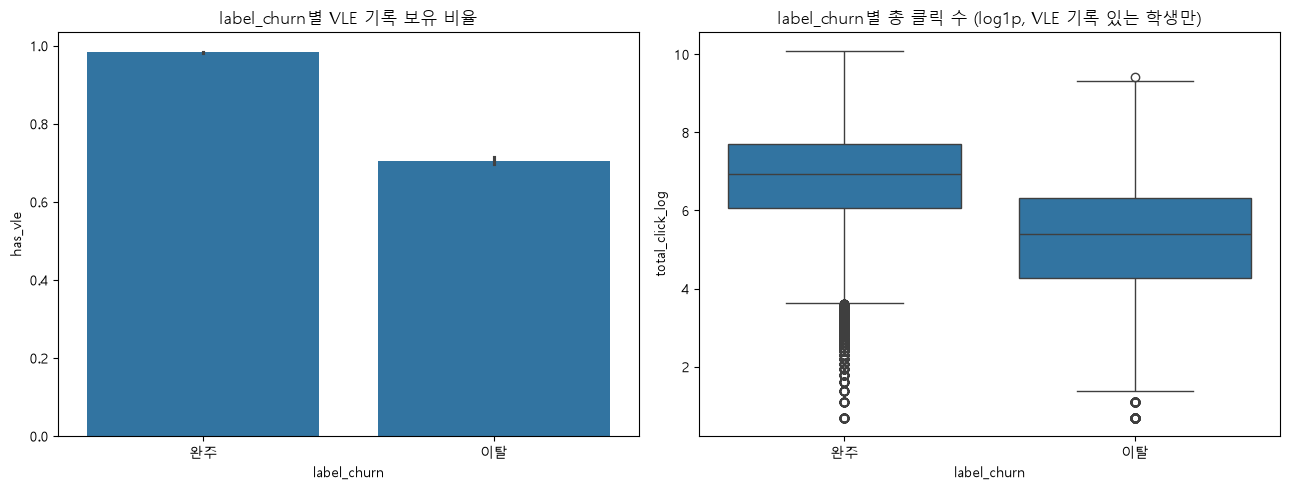

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=r, x='label_churn', y='has_vle', ax=axes[0])
axes[0].set_title('label_churn별 VLE 기록 보유 비율')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['완주', '이탈'])

vle_box = r[r['has_vle']].copy()
vle_box['total_click_log'] = np.log1p(vle_box['total_click'])
sns.boxplot(data=vle_box, x='label_churn', y='total_click_log', ax=axes[1])
axes[1].set_title('label_churn별 총 클릭 수 (log1p, VLE 기록 있는 학생만)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['완주', '이탈'])

plt.tight_layout()
plt.show()

#### 설명

완주 그룹은 98.3%가 VLE 기록을 남기는 반면 이탈 그룹은 70.6%만 기록이 있다 — 이탈 그룹 3명 중 1명은 온라인 학습활동 흔적조차 없다. VLE 기록이 있는 학생만 놓고 봐도 완주 그룹의 총 클릭 수(중앙값 1,030)가 이탈 그룹(중앙값 221.5)보다 약 4.6배 많고, 활동 일수도 완주 63일 vs 이탈 15일로 크게 차이 난다. 즉 제출 여부와 별개로 온라인 접속 자체가 이탈 그룹에서 뚜렷하게 줄어든다.

04번 Q1의 '제출 이력 없는' 고위험군(6,750명)만 따로 보면, 이 중 VLE 기록이 있는 비율은 50.9%로 완전히 발길을 끊은 것은 아니다 — 절반 정도는 로그인은 했지만 과제는 한 번도 내지 않은 것이다. 이 그룹 내에서도 label_churn별로 VLE 기록 보유 비율이 갈리는데(완주 73.0% vs 이탈 45.7%), 제출을 안 했다고 해서 곧바로 완전 이탈로 이어지는 것은 아니라는 점을 보여준다.

## Q4. studentInfo.csv 전체 기준 이탈률 병기

#### 배경

04번 Q1에서 짚은 대표성 문제 — studentAssessment 기준 조인 테이블은 제출 이력이 있는 학생만 포함하므로, '제출 이력이 있는 학생 안에서의 패턴'과 '전체 학생 기준 이탈률'을 혼동하지 않도록 항상 두 기준을 병기한다.

In [11]:
# 근거 : 전체(studentInfo) 기준 vs 제출 이력 기준 이탈률 비교
overall_full = info['label_churn'].mean()
sub_roster = roster.merge(submitted_keys, on=['code_module', 'code_presentation', 'id_student'], how='inner')
overall_sub = sub_roster['label_churn'].mean()

print(f'studentInfo 전체 기준 이탈률: {overall_full:.4f} (n={len(info):,})')
print(f'제출 이력 있는 학생 기준 이탈률: {overall_sub:.4f} (n={len(sub_roster):,})')
print()

# 근거 : code_module별 두 기준 비교
full_by_mod = info.groupby('code_module')['label_churn'].mean().round(4)
sub_by_mod = sub_roster.groupby('code_module')['label_churn'].mean().round(4)
comp = pd.DataFrame({'전체기준': full_by_mod, '제출이력기준': sub_by_mod})
comp['차이'] = (comp['전체기준'] - comp['제출이력기준']).round(4)
print(comp.sort_values('전체기준', ascending=False))

studentInfo 전체 기준 이탈률: 0.3116 (n=32,593)
제출 이력 있는 학생 기준 이탈률: 0.1816 (n=25,843)

               전체기준  제출이력기준      차이
code_module                        
CCC          0.4454  0.3120  0.1334
DDD          0.3587  0.2298  0.1289
FFF          0.3096  0.1857  0.1239
BBB          0.3019  0.1446  0.1573
EEE          0.2461  0.1049  0.1412
AAA          0.1684  0.1333  0.0351
GGG          0.1152  0.0516  0.0636


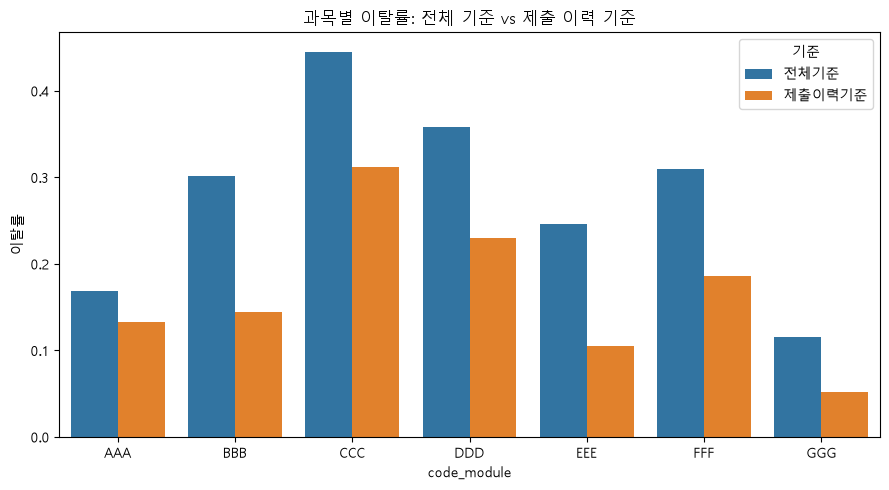

In [12]:
comp_plot = comp.reset_index().melt(id_vars='code_module', value_vars=['전체기준', '제출이력기준'],
                                     var_name='기준', value_name='이탈률')
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=comp_plot, x='code_module', y='이탈률', hue='기준', ax=ax)
ax.set_title('과목별 이탈률: 전체 기준 vs 제출 이력 기준')
plt.tight_layout()
plt.show()

#### 설명

전체 기준 이탈률은 **31.16%**, 제출 이력이 있는 학생만 보면 **18.16%**로 13%p 차이가 난다. 제출 이력 기준 표본은 애초에 '한 번이라도 시도한' 학생만 남아 있으므로 이탈률이 구조적으로 낮게 나올 수밖에 없다.

과목별로도 이 차이는 일관되게 나타나는데, CCC(13.3%p)·BBB(15.7%p)·EEE(14.1%p) 차이가 크고 AAA(3.5%p)는 상대적으로 작다. 즉 과목별 이탈률 순위(CCC 최고, GGG 최저) 자체는 두 기준에서 동일하게 유지되지만, 절대 수치는 어느 기준을 쓰느냐에 따라 크게 달라진다. 이후 어떤 분석에서든 '제출 이력 기준'으로 이탈률을 언급할 때는 반드시 전체 기준 수치를 함께 표기해야 혼동을 막을 수 있다.

## Q5. is_banked 해석 확정 — date_registration 비교

#### 배경

04번 7장 Q3에서 완주 그룹의 is_banked 비율은 0.9%, 이탈 그룹은 3.3%로 3배 이상 차이가 확인됐다. studentRegistration.csv의 `date_registration`(등록 시점)과 비교해, is_banked=1을 받은 학생이 이번 학기에 아예 등록조차 늦었는지 확인한다.

In [13]:
# 근거 : 제출 건 기준 df에 등록 시점 조인
df_reg = df.merge(reg[['code_module', 'code_presentation', 'id_student', 'date_registration']],
                   on=['code_module', 'code_presentation', 'id_student'], how='left')

print('is_banked별 date_registration (제출 건 기준):')
print(df_reg.groupby('is_banked')['date_registration'].agg(['mean', 'median', 'count']).round(2))
print()

# 근거 : 개강 이후(양수) 등록 = 늦은 등록
df_reg['late_reg'] = df_reg['date_registration'] > 0
print('is_banked별 개강 이후(늦은) 등록 비율:')
print(df_reg.groupby('is_banked')['late_reg'].mean().round(4))
print()

# 근거 : 학생 단위로도 확인 (해당 학생이 한 번이라도 is_banked=1을 받았는지)
stu_banked = df.groupby(['code_module', 'code_presentation', 'id_student'])['is_banked'].max().reset_index()
stu_banked = stu_banked.merge(reg[['code_module', 'code_presentation', 'id_student', 'date_registration']],
                               on=['code_module', 'code_presentation', 'id_student'], how='left')
print('학생 단위 is_banked 여부별 date_registration:')
print(stu_banked.groupby('is_banked')['date_registration'].agg(['mean', 'median', 'count']).round(2))

is_banked별 date_registration (제출 건 기준):
            mean  median   count
is_banked                       
0         -65.92   -53.0  172000
1         -67.40   -53.0    1905

is_banked별 개강 이후(늦은) 등록 비율:
is_banked
0    0.0065
1    0.0602
Name: late_reg, dtype: float64

학생 단위 is_banked 여부별 date_registration:
            mean  median  count
is_banked                      
0         -66.26   -53.0  25314
1         -70.16   -58.0    525


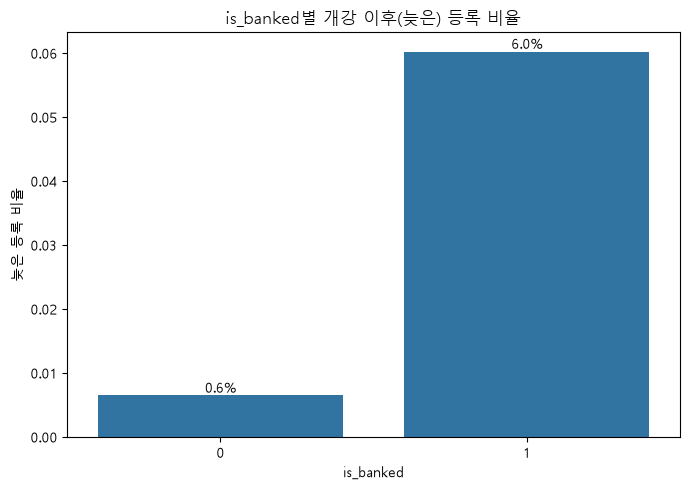

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
late_rate = df_reg.groupby('is_banked')['late_reg'].mean()
sns.barplot(x=late_rate.index.astype(str), y=late_rate.values, ax=ax)
ax.set_title('is_banked별 개강 이후(늦은) 등록 비율')
ax.set_xlabel('is_banked')
ax.set_ylabel('늦은 등록 비율')
for i, v in enumerate(late_rate.values):
    ax.text(i, v, f'{v:.1%}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

#### 설명

date_registration의 평균/중앙값 자체는 is_banked 0과 1 사이에 큰 차이가 없다(둘 다 개강 약 53~58일 전 등록). 하지만 **개강 이후(늦은) 등록 비율**을 보면 is_banked=0은 0.65%인 반면 is_banked=1은 6.02%로 약 9배 높다. 즉 절대다수는 여전히 개강 전에 등록하지만, '개강 이후 뒤늦게 등록한' 소수 집단에 is_banked=1이 몰려 있다.

이는 04번 Q3에서 발견한 is_banked-이탈 상관관계에 대한 부분적 설명이 된다 — is_banked는 단순한 성적 이월 표시가 아니라, 그중 일부는 '이번 학기 등록 자체가 늦어 이전 결과를 그대로 이월받은' 경우를 포함하고 있을 가능성이 있다. 다만 늦은 등록 비율이 6%에 불과해 is_banked-이탈 관계 전체를 설명하지는 못하며, 나머지는 다른 요인(예: 과목 재수강 패턴 등)을 봐야 할 것으로 보인다.

## Q6. 미제출 평가(결석) 식별 — 놓친 평가 비중과 이탈

#### 배경

studentAssessment.csv는 '제출한 기록'만 담고 있어 어떤 평가를 아예 내지 않았는지는 보이지 않는다. 04번 7장 Q6에서 weight를 단순 비교했을 때 결론이 나지 않았던 것도 이와 맞닿아 있다. assessments.csv의 과목-학기별 전체 평가 로스터와 실제 제출 목록을 비교해 학생별 '미제출 평가'와 그 weight를 파생시킨다.

04번에서 확인했듯 Exam(weight=100)은 이탈 시점상 구조적으로 놓칠 수밖에 없는 평가이므로, 여기서는 **Exam을 제외한 TMA/CMA만** 미제출 대상으로 삼는다.

In [15]:
# 근거 : 학생별 수강 과목의 전체 평가 로스터(기대값) 생성
expected = roster[['code_module', 'code_presentation', 'id_student']].merge(
    asm[['id_assessment', 'code_module', 'code_presentation', 'assessment_type', 'weight']],
    on=['code_module', 'code_presentation'], how='left')

# 근거 : 실제 제출 목록과 anti-join하여 미제출 건 식별
submitted_pairs = df[['code_module', 'code_presentation', 'id_student', 'id_assessment']].drop_duplicates()
submitted_pairs['submitted'] = True

merged = expected.merge(submitted_pairs, on=['code_module', 'code_presentation', 'id_student', 'id_assessment'], how='left')
merged['submitted'] = merged['submitted'].notna()  # True/NaN -> bool (fillna 다운캐스팅 이슈 회피)
missing = merged[~merged['submitted']]

print(f'전체 기대 평가 조합: {len(expected):,}건 / 미제출(결석): {len(missing):,}건')
print(missing['assessment_type'].value_counts())

전체 기대 평가 조합: 323,925건 / 미제출(결석): 150,013건
assessment_type
TMA     63992
CMA     53953
Exam    32068
Name: count, dtype: int64


In [16]:
# 근거 : Exam 제외, 학생별 미제출 weight 합·건수
miss_noexam = missing[missing['assessment_type'] != 'Exam']
miss_weight = miss_noexam.groupby(['code_module', 'code_presentation', 'id_student'])['weight'].sum().reset_index()
miss_weight.columns = ['code_module', 'code_presentation', 'id_student', 'missing_weight']
miss_count = miss_noexam.groupby(['code_module', 'code_presentation', 'id_student']).size().reset_index(name='missing_count')

r = roster.merge(miss_weight, on=['code_module', 'code_presentation', 'id_student'], how='left')
r = r.merge(miss_count, on=['code_module', 'code_presentation', 'id_student'], how='left')
r['missing_weight'] = r['missing_weight'].fillna(0)
r['missing_count'] = r['missing_count'].fillna(0)
r['any_missing'] = r['missing_count'] > 0

print('label_churn별 missing_weight(Exam 제외) 통계:')
print(r.groupby('label_churn')['missing_weight'].agg(['mean', 'median', 'count']).round(2))
print()
print('label_churn별 하나라도 놓친 학생 비율:')
print(r.groupby('label_churn')['any_missing'].mean().round(4))
print()

# 근거 : 고비중(weight>=20) 평가를 놓친 경우
high_w = miss_noexam[miss_noexam['weight'] >= 20]
high_w_miss = high_w.groupby(['code_module', 'code_presentation', 'id_student']).size().reset_index(name='high_w_miss')
r = r.merge(high_w_miss, on=['code_module', 'code_presentation', 'id_student'], how='left')
r['high_w_miss'] = r['high_w_miss'].fillna(0)
r['any_high_w_miss'] = r['high_w_miss'] > 0

print('고비중(weight>=20) 평가를 하나라도 놓친 학생 비율, label_churn별:')
print(r.groupby('label_churn')['any_high_w_miss'].mean().round(4))

label_churn별 missing_weight(Exam 제외) 통계:
              mean  median  count
label_churn                      
0            18.91     0.0  22437
1            84.80   100.0  10156

label_churn별 하나라도 놓친 학생 비율:
label_churn
0    0.4009
1    0.9913
Name: any_missing, dtype: float64

고비중(weight>=20) 평가를 하나라도 놓친 학생 비율, label_churn별:
label_churn
0    0.2107
1    0.7567
Name: any_high_w_miss, dtype: float64


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37808\4159864565.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['완주', '이탈'])
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37808\4159864565.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['완주', '이탈'])


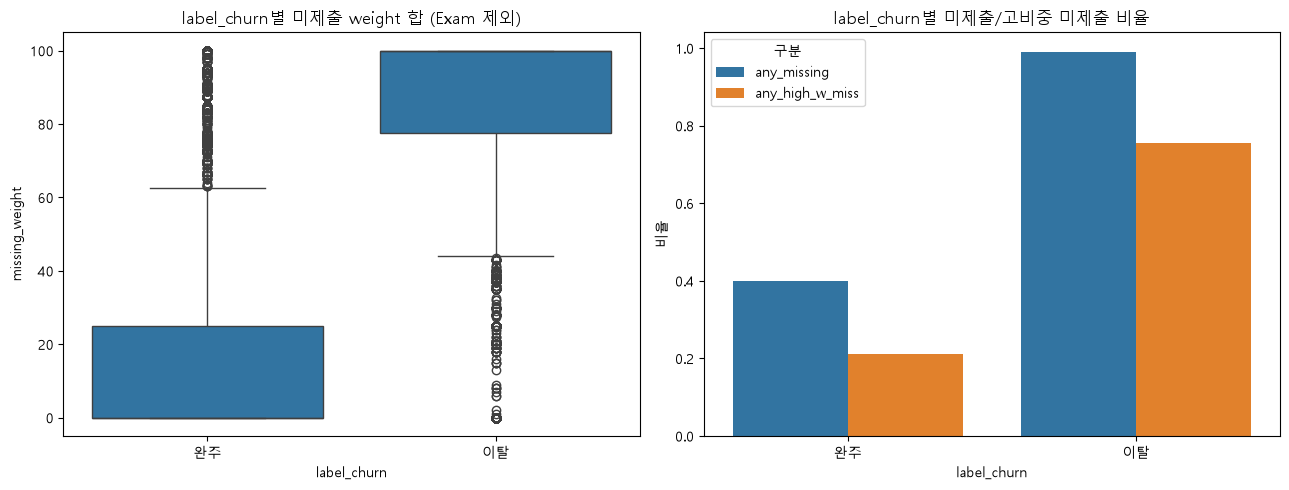

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=r, x='label_churn', y='missing_weight', ax=axes[0])
axes[0].set_title('label_churn별 미제출 weight 합 (Exam 제외)')
axes[0].set_xticklabels(['완주', '이탈'])

rate_df = r.groupby('label_churn')[['any_missing', 'any_high_w_miss']].mean().reset_index().melt(
    id_vars='label_churn', var_name='구분', value_name='비율')
sns.barplot(data=rate_df, x='label_churn', y='비율', hue='구분', ax=axes[1])
axes[1].set_title('label_churn별 미제출/고비중 미제출 비율')
axes[1].set_xticklabels(['완주', '이탈'])

plt.tight_layout()
plt.show()

#### 설명

Exam을 제외한 평가만 놓고 봐도 완주-이탈 간 격차가 뚜렷하다. 완주 그룹의 미제출 weight 합은 평균 18.91(중앙값 0 — 절반 이상이 하나도 안 놓침)인 반면, 이탈 그룹은 평균 84.80(중앙값 100 — 사실상 거의 모든 평가를 놓침)이다. 하나라도 평가를 놓친 학생 비율도 완주 40.1% vs 이탈 99.1%로 극명하게 갈린다. 고비중(weight≥20) 평가만 좁혀 봐도 완주 21.1% vs 이탈 75.7%로 동일한 패턴이 유지된다.

04번 7장 Q6에서 '제출한 평가의 weight 평균'을 비교했을 때는 뚜렷한 차이가 나지 않았지만, 관점을 뒤집어 '놓친 평가의 weight'로 보니 이탈 그룹이 확연히 더 많은 비중을 놓치고 있다는 것이 드러난다. 다만 이 지표는 이탈의 '원인'이라기보다 이탈 과정 자체(제출을 멈추면서 자연히 이후 평가도 놓치게 됨)를 반영하는 결과 지표에 가깝다는 점은 유의해야 한다 — 시계열상 '어떤 평가를 처음 놓쳤는지'와 '그 시점이 실제 이탈 시점보다 앞서는지'를 봐야 인과 방향을 더 명확히 할 수 있다.

# 3. 종합 정리

| 질문 | 핵심 결과 |
|---|---|
| Q1. courses.csv (길이/시즌) | 길이 상관계수 -0.17, 시즌 차이(B 30.2% vs J 26.7%)도 작음 → 과목별 이탈률 차이는 학기 구조가 아니라 과목 자체 효과로 유지됨 |
| Q2. date_unregistration | 마지막 제출 후 평균 39.4일(중앙값 34일) 뒤 공식 취소. 제출 이력 없는 Withdrawn(53.1%)은 대부분 개강 시점 부근에 이탈 |
| Q3. studentVle.csv | 이탈 그룹 29.4%는 VLE 기록조차 없음. 기록이 있어도 클릭 수 중앙값이 완주 대비 약 4.6배 낮음. 제출 이력 없는 고위험군도 절반(50.9%)은 VLE 기록은 남김 |
| Q4. 전체 vs 제출이력 기준 이탈률 | 전체 31.16% vs 제출이력기준 18.16% (13%p 차이). 과목별 순위는 동일하나 절대 수치는 기준에 따라 크게 달라짐 |
| Q5. is_banked × date_registration | 등록 시점 자체는 큰 차이 없으나, 개강 이후 늦은 등록 비율이 is_banked=1에서 9배 높음(6.02% vs 0.65%) — 부분적 설명 |
| Q6. 미제출 평가(결석) | Exam 제외 미제출 weight 합 완주 18.91 vs 이탈 84.80(중앙값 0 vs 100). 다만 원인이라기보다 이탈 과정의 결과 지표에 가까움 |


이번 조인으로 04번 8장의 6개 질문은 모두 실제 수치로 확인됐다. Q1·Q4는 04번의 기존 결론을 보강했고, Q2·Q3·Q5·Q6은 새로운 파생 지표(취소-제출 간격, VLE 활동량, 늦은 등록 비율, 미제출 weight)를 만들어 이탈 패턴을 더 세분화했다. 다음 단계로 넘어간다면 Q6에서 지적한 인과 방향 문제(놓친 평가가 이탈의 원인인지 결과인지)를 시계열 순서로 다시 짚어보는 것이 유효할 것으로 보인다.

다음 IPYNB 파일에선 아래를 검증한다.

1. **Q2(취소-제출 간격) × Q6(미제출 평가)**: 학생이 "평가를 처음 놓친 시점"이 실제 "등록취소일"보다 앞서는가? 05번 Q6 설명에서 지적한 인과 방향(놓친 평가가 이탈의 원인인지 결과인지) 문제를 시계열 순서로 확인한다.
2. **Q3(VLE 조인) 세분화**: 05번은 총 클릭 수·활동 일수만 집계했다. vle.csv의 `activity_type`(자료 유형)까지 조인하면 이탈 그룹이 구체적으로 어떤 유형의 활동에서 더 크게 빠지는지 볼 수 있다.
3. **Q3의 시계열 후속**: 학기 전반부 대비 후반부 클릭 수 변화(감소 추세)를 보면 이탈의 조기 경보 신호로 쓸 수 있는지 확인할 수 있다.
4. **Q5(is_banked) 재해석**: is_banked는 정의상 재수강(`num_of_prev_attempts>0`)과 강하게 얽혀 있다. 재수강 여부·is_banked·이탈률을 함께 봐야 05번에서 "부분적 설명"으로 남긴 결론을 더 명확히 할 수 있다.

- **범주형 변수 간 독립성**: gender·region·highest_education·imd_band·age_band·disability·code_module·code_presentation 8개 변수가 서로 얼마나 겹치는 정보를 담고 있는지 카이제곱검정과 Cramér's V로 확인한다. 이후 모델링에서 여러 인구통계 변수를 동시에 넣을 때 중복 신호가 있는지 미리 점검하는 목적이다.
- **수치형 파생변수 간 다중공선성**: 지금까지 파생시킨 참여도 지표(총 클릭 수, 활동 일수, 제출 건수, 평균 점수, 미제출 weight 등)를 한 테이블에 모아 상관행렬과 VIF(분산팽창지수)를 계산한다. 이 지표들은 개념적으로 "얼마나 활발히 참여했는가"라는 하나의 축을 여러 각도에서 재는 것이라 서로 강하게 겹칠 가능성이 높다.